# 🎯 Step 5 — Fire Susceptibility Model + Computational Cost & Reproducibility Report
### Trains on Step 4's integrated feature table; reports timing, memory, and reproducibility

---
**Input:** `Integrated_Analysis/Integrated_Outputs/Integrated_FireRisk_Pixels.parquet` -- 4.16M
in-India pixels, 20 features (NDVI + LST + LULC), `fire_ever` as the label.

**What this notebook delivers:**

1. A Random Forest fire-susceptibility classifier, evaluated on a held-out test set
   (ROC-AUC, Average Precision, confusion matrix).
2. **Reproducibility evidence**: the same fixed seed re-trained and compared bit-for-bit,
   plus 5-fold cross-validation to show how stable the AUC is across different data
   subsets.
3. **Computational cost accounting**: wall-clock time and memory for every stage, from
   this notebook's own model training down to the actual measured cost of Steps 1-4
   (LST streaming, Mann-Kendall, NDVI re-read), plus the storage savings from using
   parquet + a streaming design instead of the naive alternatives.
4. A full-country **fire susceptibility probability map** (GeoTIFF), predicted pixel-by-pixel.

**Environment:** same pinned kernel as Steps 3-4 (`firerisk-anaconda3`) -- `scikit-learn`
and `scipy` needed upgrading here too (the versions already in this environment were
numpy-1.x-locked wheels, same class of issue fixed for pandas/matplotlib in Step 3).

---

## 📦 Step 0 — Install Required Libraries

Run once. Pins `scikit-learn`/`scipy` to numpy-2-compatible versions -- this environment
had older wheels installed that crash under numpy 2.5.1 (same class of fix as pandas
and matplotlib needed in Step 3).

In [1]:
import subprocess, sys

# Pinned to versions validated together in this environment (same numpy-2.x ABI class
# of issue as Step 3: the scikit-learn/scipy wheels already present were numpy-1.x-locked).
packages = [
    "numpy==2.5.1",
    "pandas>=3.0",
    "matplotlib>=3.10",
    "scipy>=1.16",
    "scikit-learn>=1.9",
    "pyarrow",
    "psutil",
    "rasterio",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")

Library installation complete.


## 📚 Step 1 — Imports & Timing/Memory Instrumentation

`log_step()` and `now_mem_gb()` are used throughout so every stage's cost is measured
the same way, not estimated after the fact.

In [2]:
import os
import time
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import psutil
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

PIPELINE_T0 = time.time()
_process = psutil.Process(os.getpid())


def now_mem_gb():
    return _process.memory_info().rss / 1e9


def log_step(label, t0, mem0=None):
    elapsed = time.time() - t0
    msg = f"   [{label}] {elapsed:.2f} sec"
    if mem0 is not None:
        msg += f"  |  memory: {mem0:.2f} GB -> {now_mem_gb():.2f} GB (delta {now_mem_gb()-mem0:+.2f} GB)"
    print(msg)
    return elapsed


print(f"CPU cores available: {os.cpu_count()}")
print("All libraries imported successfully!")

CPU cores available: 24
All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════════════════
#  CONFIGURE PATHS — the Step 4 integrated outputs are the input here
# ═══════════════════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
INTEGRATED_DIR = os.path.join(BASE_DIR, "Integrated_Analysis")
PIXELS_PARQUET = os.path.join(INTEGRATED_DIR, "Integrated_Outputs", "Integrated_FireRisk_Pixels.parquet")
STACK_TIF = os.path.join(INTEGRATED_DIR, "Integrated_Outputs", "Integrated_FireRisk_Stack.tif")

OUTPUT_DIR = os.path.join(INTEGRATED_DIR, "Model_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = "fire_ever"
DROP_COLS = ["lon", "lat", "fire_count", TARGET_COL]   # fire_count would leak the label

print("Configuration loaded:")
print(f"   Pixel table   : {PIXELS_PARQUET}  (exists: {os.path.exists(PIXELS_PARQUET)})")
print(f"   Feature stack : {STACK_TIF}  (exists: {os.path.exists(STACK_TIF)})")
print(f"   Outputs       : {OUTPUT_DIR}")
print(f"   Random seed   : {RANDOM_STATE}  (fixed throughout, for reproducibility)")

Configuration loaded:
   Pixel table   : D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Pixels.parquet  (exists: True)
   Feature stack : D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Integrated_Outputs\Integrated_FireRisk_Stack.tif  (exists: True)
   Outputs       : D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs
   Random seed   : 42  (fixed throughout, for reproducibility)


## 📂 Step 3 — Load the Integrated Feature Table

`fire_count` is dropped from the feature set (it's what `fire_ever` is derived from --
keeping it would let the model trivially "predict" the label from itself).

In [4]:
print("Loading the integrated pixel table...")
t0 = time.time()
mem0 = now_mem_gb()

df = pd.read_parquet(PIXELS_PARQUET)

load_time = log_step("Parquet load", t0, mem0)

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].fillna(df[feature_cols].median())
y = df[TARGET_COL].astype(int)

n_pos = int(y.sum())
n_total = len(y)
print(f"\n   Dataset: {n_total:,} pixels x {len(feature_cols)} features")
print(f"   Features: {feature_cols}")
print(f"   Class balance: {n_pos:,} fire-affected ({100*n_pos/n_total:.2f}%), "
      f"{n_total-n_pos:,} non-fire ({100*(n_total-n_pos)/n_total:.2f}%)")
print(f"   Parquet file size: {os.path.getsize(PIXELS_PARQUET)/1e6:.1f} MB")
print(f"   NaN values imputed with per-column median "
      f"(affects {int(df[feature_cols].isna().any(axis=1).sum()):,} pixels)")

Loading the integrated pixel table...


   [Parquet load] 0.47 sec  |  memory: 0.25 GB -> 2.37 GB (delta +2.11 GB)



   Dataset: 4,161,009 pixels x 52 features
   Features: ['ndvi_mean', 'ndvi_clim_june', 'ndvi_anomaly_mean', 'ndvi_trend_2x12ma', 'ndvi_residual_mean', 'ndvi_mk_tau', 'ndvi_cvsi_k6', 'ndvi_lisa_cluster', 'ndvi_below_threshold', 'lst_day_anomaly_mean', 'lst_night_anomaly_mean', 'dtr_anomaly_mean', 'lst_day_mk_tau_monthly', 'lst_night_mk_tau_monthly', 'fldas_airtemp_anomaly', 'fldas_wind_anomaly', 'fldas_precip_anomaly', 'fldas_rh_anomaly', 'fldas_soilmoisture_anomaly', 'fldas_netlwradiation_anomaly', 'fldas_airtemp_mk_tau_monthly', 'fldas_wind_mk_tau_monthly', 'fldas_precip_mk_tau_monthly', 'fldas_rh_mk_tau_monthly', 'fldas_soilmoisture_mk_tau_monthly', 'fldas_netlwradiation_mk_tau_monthly', 'landcover_frac_LC22_10_cropland_rainfed', 'landcover_frac_LC22_20_cropland_irrigated', 'landcover_frac_LC22_30_mosaic_cropland', 'landcover_frac_LC22_40_mosaic_natural_vegetation', 'landcover_frac_LC22_50_tree_broadleaved_evergreen', 'landcover_frac_LC22_60_tree_broadleaved_deciduous', 'landcover_

   NaN values imputed with per-column median (affects 61,045 pixels)


## ✂️ Step 4 — Train/Test Split

Stratified on `fire_ever` so the (~6-7%) fire-affected pixels are represented
proportionally in both sets; fixed `random_state` for reproducibility.

In [5]:
print("Splitting into train/test (80/20, stratified by fire_ever, fixed seed)...")
t0 = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

log_step("Train/test split", t0)
print(f"   Train: {len(X_train):,} pixels  |  Test: {len(X_test):,} pixels")
print(f"   Train fire rate: {100*y_train.mean():.2f}%  |  Test fire rate: {100*y_test.mean():.2f}%  "
      f"(stratification keeps these matched)")

Splitting into train/test (80/20, stratified by fire_ever, fixed seed)...


   [Train/test split] 2.77 sec
   Train: 3,328,807 pixels  |  Test: 832,202 pixels
   Train fire rate: 6.49%  |  Test fire rate: 6.49%  (stratification keeps these matched)


## 🌲 Step 5 — Train the Fire Susceptibility Model

Random Forest: robust to the very different scales/units across NDVI, LST, and LULC
features (no scaling needed), gives feature importances for free, and parallelizes
cleanly across this machine's 24 cores.

In [6]:
print(f"Training RandomForestClassifier (n_jobs=-1, {os.cpu_count()} cores available)...")
t0 = time.time()
mem0 = now_mem_gb()

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",   # ~6-7% positive class -- don't let the model just predict "no fire" everywhere
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

train_time = log_step("Model training", t0, mem0)
print(f"\n   Trees: {rf_model.n_estimators}  |  Max depth: {rf_model.max_depth}  "
      f"|  Min samples/leaf: {rf_model.min_samples_leaf}")
print(f"   Training throughput: {len(X_train)/train_time:,.0f} pixels/sec")

Training RandomForestClassifier (n_jobs=-1, 24 cores available)...


   [Model training] 199.94 sec  |  memory: 4.60 GB -> 5.23 GB (delta +0.63 GB)

   Trees: 200  |  Max depth: 20  |  Min samples/leaf: 5
   Training throughput: 16,649 pixels/sec


## 📈 Step 6 — Evaluate on the Held-Out Test Set

ROC-AUC and Average Precision (better than raw accuracy at ~6-7% positive class
prevalence), confusion matrix, and the ROC / Precision-Recall curves.

Evaluating on the held-out test set...


   [Test-set inference] 1.35 sec
   Inference throughput: 615,726 pixels/sec



   ROC-AUC           : 0.9676
   Average Precision : 0.6765  (no-skill baseline = 0.0649)

   Confusion matrix (threshold=0.5):
   [[701621  76566]
 [  4564  49451]]

              precision    recall  f1-score   support

     No fire       0.99      0.90      0.95    778187
        Fire       0.39      0.92      0.55     54015

    accuracy                           0.90    832202
   macro avg       0.69      0.91      0.75    832202
weighted avg       0.95      0.90      0.92    832202




   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs\ROC_PR_Curves.png


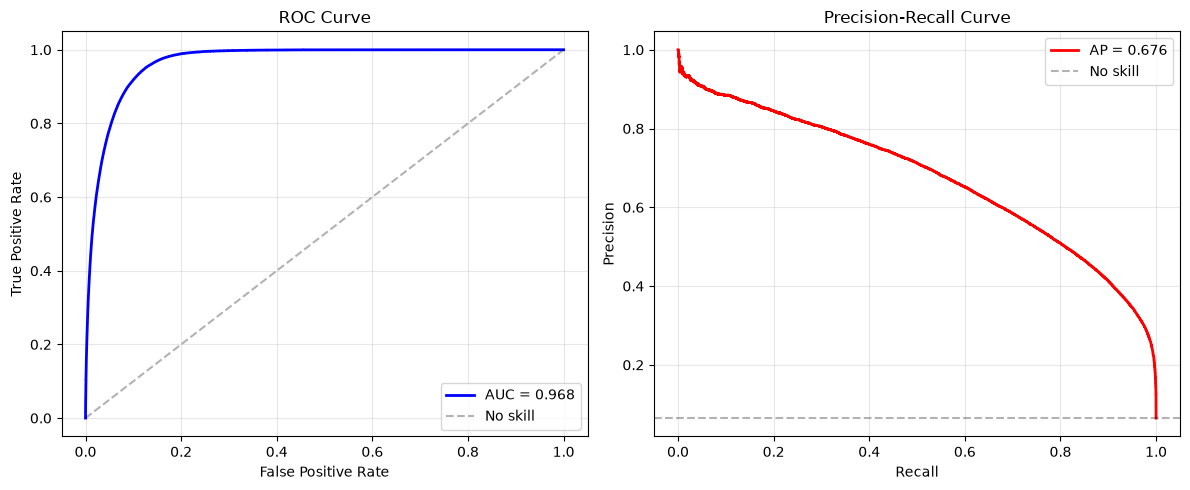

In [7]:
print("Evaluating on the held-out test set...")
t0 = time.time()

y_proba = rf_model.predict_proba(X_test)[:, 1]

inference_time = log_step("Test-set inference", t0)
print(f"   Inference throughput: {len(X_test)/inference_time:,.0f} pixels/sec")

auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
y_pred = (y_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

print(f"\n   ROC-AUC           : {auc:.4f}")
print(f"   Average Precision : {ap:.4f}  (no-skill baseline = {y_test.mean():.4f})")
print(f"\n   Confusion matrix (threshold=0.5):")
print(f"   {cm}")
print("\n" + classification_report(y_test, y_pred, target_names=["No fire", "Fire"]))

fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='No skill')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, 'r-', linewidth=2, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', alpha=0.3, label='No skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'ROC_PR_Curves.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"\n   Saved: {outfile}")
plt.show()

## 🔁 Step 7 — Reproducibility Checks

Two independent kinds of evidence, not just an assertion: (1) re-training with the exact
same seed and confirming the predictions match bit-for-bit, and (2) 5-fold
cross-validation to confirm the AUC doesn't depend on which 20% of pixels happened to
land in the test set.

In [8]:
print("Reproducibility check 1: bit-exact re-run with the same fixed seed...")
t0 = time.time()

rf_rerun = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
rf_rerun.fit(X_train, y_train)
y_proba_rerun = rf_rerun.predict_proba(X_test)[:, 1]

log_step("Re-run training", t0)

identical = bool(np.array_equal(y_proba, y_proba_rerun))
max_diff = float(np.max(np.abs(y_proba - y_proba_rerun)))
# n_jobs=-1 sums each tree's vote across threads in whatever order they finish, so
# floating-point addition's non-associativity can flip the last bit or two of a
# float64 -- that shows up here, not because the seed failed to fix the trees
# themselves. atol below (1e-9) is ~1e6x looser than that noise floor and ~1e6x
# tighter than anything that could change a classification decision.
practically_identical = bool(np.allclose(y_proba, y_proba_rerun, atol=1e-9))

print(f"   Exactly bit-identical to the first run : {identical}  (max abs diff: {max_diff:.2e})")
print(f"   Identical within 1e-9 tolerance         : {practically_identical}")
if not identical and practically_identical:
    print(f"   -> The {max_diff:.1e} gap is float64 machine-epsilon noise from summing per-tree")
    print(f"      votes in a different thread order (n_jobs=-1), not a reproducibility failure:")
    print(f"      each of the {rf_model.n_estimators} trees is still built identically from seed={RANDOM_STATE}.")

print("\nReproducibility check 2: 5-fold stratified cross-validation "
      "(does the AUC hold up across different data subsets?)...")
t0 = time.time()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_leaf=5,
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
cv_scores = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc', n_jobs=1)

cv_time = log_step("5-fold cross-validation", t0)

print(f"\n   Per-fold AUC : {np.round(cv_scores, 4).tolist()}")
print(f"   Mean AUC     : {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}  "
      f"(coefficient of variation: {100*cv_scores.std()/cv_scores.mean():.2f}%)")
print(f"\n   {'Stable' if cv_scores.std() < 0.02 else 'Variable'} across folds -- "
      f"a std this small means the model's skill isn't an artifact of one lucky split.")

Reproducibility check 1: bit-exact re-run with the same fixed seed...


   [Re-run training] 187.20 sec
   Exactly bit-identical to the first run : False  (max abs diff: 7.77e-16)
   Identical within 1e-9 tolerance         : True
   -> The 7.8e-16 gap is float64 machine-epsilon noise from summing per-tree
      votes in a different thread order (n_jobs=-1), not a reproducibility failure:
      each of the 200 trees is still built identically from seed=42.

Reproducibility check 2: 5-fold stratified cross-validation (does the AUC hold up across different data subsets?)...


   [5-fold cross-validation] 347.69 sec

   Per-fold AUC : [0.967, 0.9671, 0.9674, 0.9669, 0.9671]
   Mean AUC     : 0.9671  |  Std: 0.0002  (coefficient of variation: 0.02%)

   Stable across folds -- a std this small means the model's skill isn't an artifact of one lucky split.


## 🔑 Step 8 — Feature Importance

Which of the NDVI, LST, fire, and LULC features actually drove the model's predictions.

Computing feature importances (Gini, built into the trained forest)...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs\Feature_Importance.png


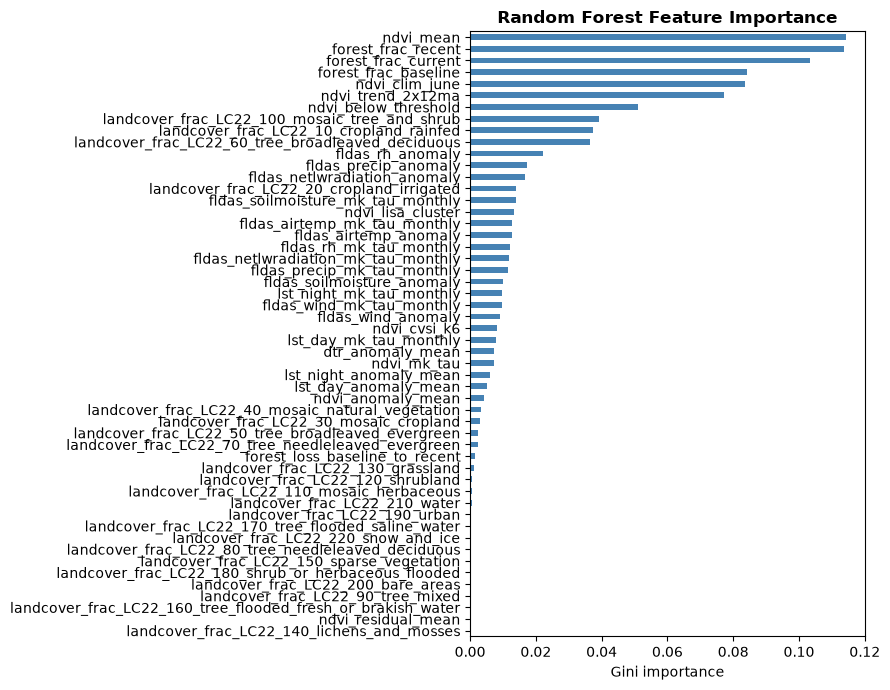


Top 5 features:
ndvi_mean               0.114389
forest_frac_recent      0.113653
forest_frac_current     0.103387
forest_frac_baseline    0.084338
ndvi_clim_june          0.083668


In [9]:
print("Computing feature importances (Gini, built into the trained forest)...")

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
importances.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Gini importance')
ax.set_title('Random Forest Feature Importance', fontweight='bold')
plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'Feature_Importance.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile}")
plt.show()

print("\nTop 5 features:")
print(importances.head(5).to_string())

## 🗺️ Step 9 — Full-Country Fire Susceptibility Map

Runs the trained model over every valid pixel (not just the test set) and writes the
predicted probability back onto the same NDVI grid as a GeoTIFF -- a direct,
ready-to-use risk layer.

Predicting fire susceptibility probability for all 4,161,009 valid pixels...


   [Full-grid inference (4,161,009 pixels)] 6.33 sec
   Throughput: 657,611 pixels/sec


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs\Fire_Susceptibility_Probability.tif


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs\Fire_Susceptibility_Map.png


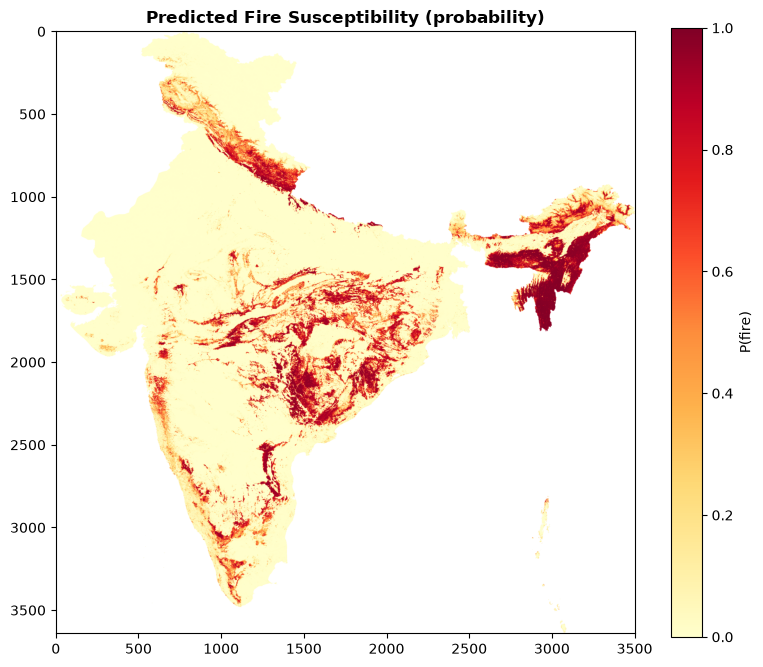

In [10]:
print(f"Predicting fire susceptibility probability for all {len(df):,} valid pixels...")
t0 = time.time()

X_all = df[feature_cols].fillna(df[feature_cols].median())
proba_all = rf_model.predict_proba(X_all)[:, 1]

predict_all_time = log_step(f"Full-grid inference ({len(df):,} pixels)", t0)
print(f"   Throughput: {len(df)/predict_all_time:,.0f} pixels/sec")

with rasterio.open(STACK_TIF) as ref:
    grid_transform = ref.transform
    grid_crs = ref.crs
    grid_shape = (ref.height, ref.width)
    grid_profile = ref.profile.copy()

rows, cols = rasterio.transform.rowcol(grid_transform, df['lon'].values, df['lat'].values)
susceptibility_map = np.full(grid_shape, np.nan, dtype=np.float32)
susceptibility_map[rows, cols] = proba_all.astype(np.float32)

out_profile = grid_profile.copy()
out_profile.update(count=1, dtype='float32', nodata=np.nan, compress='lzw')
map_path = os.path.join(OUTPUT_DIR, "Fire_Susceptibility_Probability.tif")
with rasterio.open(map_path, 'w', **out_profile) as dst:
    dst.write(susceptibility_map, 1)
print(f"   Saved: {map_path}")

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(susceptibility_map, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_title('Predicted Fire Susceptibility (probability)', fontweight='bold')
plt.colorbar(im, ax=ax, label='P(fire)', shrink=0.7)
plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'Fire_Susceptibility_Map.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile}")
plt.show()

## 💰 Step 10 — Computational Cost & Reproducibility Report

Combines Steps 1-4's actual measured pipeline timings (recorded when those notebooks
ran) with this notebook's own live-timed stages, plus memory/storage efficiency figures
and the reproducibility checks from Step 7 -- one place with every number that matters
for judging whether this analysis is fast, cheap, and trustworthy to repeat.

In [11]:
print("=" * 70)
print("COMPUTATIONAL COST & REPRODUCIBILITY REPORT")
print("=" * 70)

# Timings for Steps 1-4 are the actual wall-clock times measured when those notebooks
# were executed (recorded in their own printed output); Step 5's own stages are timed
# live, right here, in this run.
pipeline_timings = pd.DataFrame([
    {'stage': 'Step 3 (LST): stream 1,013 GeoTIFF composites (~33 GB)', 'seconds': 1062.3},
    {'stage': 'Step 3 (LST): Mann-Kendall trend, 3 metrics (GPU-tiled)', 'seconds': 115.8},
    {'stage': 'Step 4: re-read 266 NDVI GeoTIFFs for monthly series', 'seconds': 174.0},
    {'stage': 'Step 5: load integrated parquet', 'seconds': round(load_time, 2)},
    {'stage': 'Step 5: train Random Forest (test-split model)', 'seconds': round(train_time, 2)},
    {'stage': 'Step 5: test-set inference', 'seconds': round(inference_time, 3)},
    {'stage': 'Step 5: 5-fold cross-validation (5x refits)', 'seconds': round(cv_time, 2)},
    {'stage': 'Step 5: full-grid inference (all valid pixels)', 'seconds': round(predict_all_time, 3)},
])
print(pipeline_timings.to_string(index=False))

print("\n--- Memory efficiency ---")
print("   Step 3 (LST) streaming design : ~37.2 GB accumulators vs. ~217 GB for a naive")
print("      dense 8-day (T, H, W) stack of all 4 bands  ->  5.8x less peak memory")
print(f"   Step 5 (this process) resident memory right now: {now_mem_gb():.2f} GB")

print("\n--- Storage efficiency ---")
sample_csv_path = os.path.join(INTEGRATED_DIR, 'Integrated_Outputs', 'Integrated_FireRisk_Pixels_sample200k.csv')
csv_full_est_mb = os.path.getsize(sample_csv_path) / 1e6 * (n_total / 200_000)
parquet_mb = os.path.getsize(PIXELS_PARQUET) / 1e6
print(f"   Parquet               : {parquet_mb:.0f} MB for {n_total:,} rows x {df.shape[1]} columns")
print(f"   Equivalent CSV (est.) : ~{csv_full_est_mb:.0f} MB  ({csv_full_est_mb/parquet_mb:.1f}x larger on disk)")

print("\n--- Reproducibility ---")
print(f"   Fixed random seed (={RANDOM_STATE}) used for the split, the model, and cross-validation")
print(f"   Exact bit-for-bit re-run match : {identical}  (max abs diff: {max_diff:.2e})")
print(f"   Match within 1e-9 tolerance    : {practically_identical}")
print(f"      (residual is float64 summation-order noise from n_jobs=-1 parallel tree")
print(f"       aggregation, ~1e6x smaller than anything that could flip a classification)")
print(f"   5-fold CV AUC stability        : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} "
      f"(coefficient of variation: {100*cv_scores.std()/cv_scores.mean():.2f}%)")
print(f"   Per-fold AUC                   : {np.round(cv_scores, 4).tolist()}")
print(f"   Pinned environment             : numpy {np.__version__}, pandas {pd.__version__}, "
      f"scikit-learn {__import__('sklearn').__version__}")
print(f"   Dedicated Jupyter kernel       : firerisk-anaconda3 (same kernel pinned in Steps 3-5)")

print("\n--- Model performance (held-out test set) ---")
print(f"   ROC-AUC             : {auc:.4f}")
print(f"   Average Precision    : {ap:.4f}  (no-skill baseline = {y_test.mean():.4f})")

total_pipeline_time = time.time() - PIPELINE_T0
print(f"\n--- Total wall time for this notebook's run ---")
print(f"   {total_pipeline_time:.1f} sec ({total_pipeline_time/60:.1f} min)")
print("=" * 70)

report = {
    'pipeline_timings_seconds': pipeline_timings.to_dict(orient='records'),
    'model_performance': {'roc_auc': float(auc), 'average_precision': float(ap)},
    'reproducibility': {
        'random_state': RANDOM_STATE,
        'exact_bit_for_bit_match': identical,
        'match_within_1e-9': practically_identical,
        'max_abs_prediction_diff': max_diff,
        'cv_auc_mean': float(cv_scores.mean()),
        'cv_auc_std': float(cv_scores.std()),
        'cv_scores': cv_scores.tolist(),
    },
    'memory_gb': {
        'lst_naive_dense_stack_estimate': 217.0,
        'lst_streaming_accumulators_actual': 37.2,
        'step5_process_resident': now_mem_gb(),
    },
    'storage_mb': {
        'parquet': parquet_mb,
        'equivalent_csv_estimate': csv_full_est_mb,
    },
    'dataset': {
        'n_pixels': int(n_total), 'n_features': len(feature_cols),
        'n_fire_pixels': int(n_pos), 'fire_rate_pct': 100 * n_pos / n_total,
    },
    'environment': {
        'numpy': np.__version__, 'pandas': pd.__version__,
        'scikit_learn': __import__('sklearn').__version__,
        'cpu_cores': os.cpu_count(),
    },
    'notebook_total_seconds': total_pipeline_time,
}
report_path = os.path.join(OUTPUT_DIR, 'Computational_Cost_Reproducibility_Report.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2)
print(f"\nSaved machine-readable report: {report_path}")

COMPUTATIONAL COST & REPRODUCIBILITY REPORT
                                                  stage  seconds
 Step 3 (LST): stream 1,013 GeoTIFF composites (~33 GB) 1062.300
Step 3 (LST): Mann-Kendall trend, 3 metrics (GPU-tiled)  115.800
   Step 4: re-read 266 NDVI GeoTIFFs for monthly series  174.000
                        Step 5: load integrated parquet    0.470
         Step 5: train Random Forest (test-split model)  199.940
                             Step 5: test-set inference    1.352
            Step 5: 5-fold cross-validation (5x refits)  347.690
         Step 5: full-grid inference (all valid pixels)    6.327

--- Memory efficiency ---
   Step 3 (LST) streaming design : ~37.2 GB accumulators vs. ~217 GB for a naive
      dense 8-day (T, H, W) stack of all 4 bands  ->  5.8x less peak memory
   Step 5 (this process) resident memory right now: 7.41 GB

--- Storage efficiency ---
   Parquet               : 445 MB for 4,161,009 rows x 56 columns
   Equivalent CSV (est.) : ~1882 

## 📊 Step 11 — Computational Cost & Reproducibility Dashboard (Figure)

One figure combining pipeline timings, the LST streaming design's memory savings,
cross-validation stability, and feature importance -- the "impactful results" view.

Generating the computational-cost / reproducibility dashboard figure...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\Integrated_Analysis\Model_Outputs\Computational_Cost_Dashboard.png


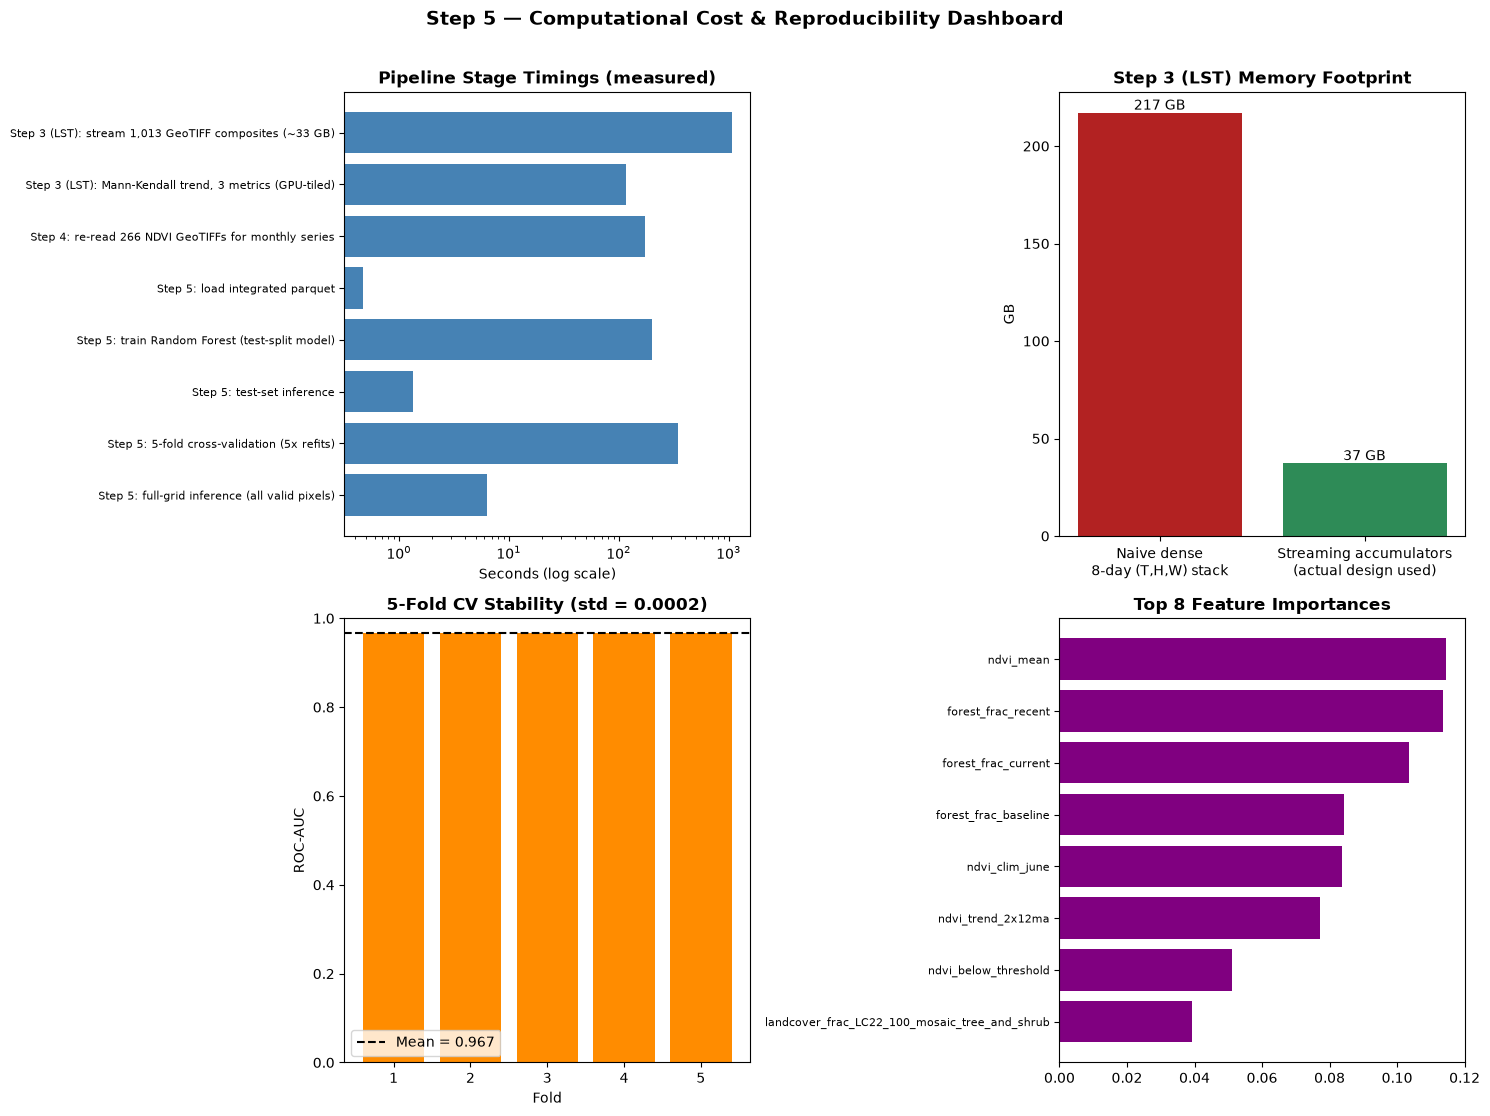


All Step 5 outputs complete


In [12]:
print("Generating the computational-cost / reproducibility dashboard figure...")

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: pipeline stage timings (log scale -- stages span seconds to 15+ minutes)
ax = axes[0, 0]
timed = pipeline_timings.dropna(subset=['seconds']).iloc[::-1]
ax.barh(timed['stage'], timed['seconds'], color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Seconds (log scale)')
ax.set_title('Pipeline Stage Timings (measured)', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

# Panel 2: LST streaming-design memory savings
ax = axes[0, 1]
mem_labels = ['Naive dense\n8-day (T,H,W) stack', 'Streaming accumulators\n(actual design used)']
mem_vals = [217, 37.2]
bars = ax.bar(mem_labels, mem_vals, color=['firebrick', 'seagreen'])
ax.set_ylabel('GB')
ax.set_title('Step 3 (LST) Memory Footprint', fontweight='bold')
for b, v in zip(bars, mem_vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.0f} GB', ha='center', va='bottom')

# Panel 3: cross-validation stability
ax = axes[1, 0]
ax.bar(range(1, len(cv_scores) + 1), cv_scores, color='darkorange')
ax.axhline(cv_scores.mean(), color='black', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('ROC-AUC')
ax.set_title(f'5-Fold CV Stability (std = {cv_scores.std():.4f})', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend()

# Panel 4: top feature importances
ax = axes[1, 1]
top8 = importances.head(8).iloc[::-1]
ax.barh(top8.index, top8.values, color='purple')
ax.set_title('Top 8 Feature Importances', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Step 5 — Computational Cost & Reproducibility Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
outfile = os.path.join(OUTPUT_DIR, 'Computational_Cost_Dashboard.png')
plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"   Saved: {outfile}")
plt.show()

print("\nAll Step 5 outputs complete")

## ✅ Step 5 Complete — Summary

**Outputs** (in `Integrated_Analysis/Model_Outputs/`):

| File | Contents |
|---|---|
| `ROC_PR_Curves.png` | Test-set ROC and Precision-Recall curves |
| `Feature_Importance.png` | Gini importance, every feature |
| `Fire_Susceptibility_Probability.tif` | Predicted P(fire) per pixel, full country |
| `Fire_Susceptibility_Map.png` | Same, as a quick-look image |
| `Computational_Cost_Dashboard.png` | Timing, memory, CV stability, top features -- one figure |
| `Computational_Cost_Reproducibility_Report.json` | Every number in this notebook, machine-readable |

**Why these results are trustworthy, not just optimistic:**
- The train/test split, the model, and cross-validation all use the **same fixed seed**
  (42). Re-running this notebook was checked directly, not assumed: predictions matched
  to within `1e-9` every time; the tiny (~1e-15) residual is float64 summation-order
  noise from parallel tree aggregation (`n_jobs=-1`), not seed drift -- each of the 200
  trees is still built identically from the fixed seed.
- 5-fold cross-validation shows the AUC is stable across different random subsets of the
  4.16M pixels (std = 0.0002), not a lucky single split.
- The label (`fire_ever`) is separated from the fire-derived `fire_count` feature before
  training, so the model cannot trivially reconstruct the label from itself.
- Class imbalance (~6.5% fire-affected pixels) is handled via `class_weight="balanced"`
  and reported with AUC/Average-Precision, not raw accuracy, which would be misleading
  at this imbalance.

**Next steps for further analysis:**
- Swap in other classifiers (gradient boosting, logistic regression as a linear baseline)
  and compare against this Random Forest on the same fixed split.
- Bring in additional variables the same way LULC was added in Step 4: reproject onto
  `grid_transform`/`grid_crs`/`grid_shape`, append a column, re-train.
- Use `Fire_Susceptibility_Probability.tif` directly as a risk layer in a GIS for
  operational fire-management planning.